# Fase 4b — Análisis NLP de Comentarios

Análisis de sentimiento y topic modeling sobre los comentarios escritos por los jugadores.

**Entradas:** `data/processed/sessions.parquet`  
**Salidas:** `data/exports/nlp_results.csv`, figuras `reports/figures/fig6_*.png`

> **Limitación crítica:** Solo **4 comentarios reales** disponibles (6 totales incluyendo spam) de 48 sesiones.
> Los resultados son estrictamente **cualitativos e ilustrativos**.
> El topic modeling con n=4 identifica patrones mínimos, no estructuras robustas.
> El modelo BERT multilingüe procesa correctamente español.

## 0. Configuración

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'src'))
from nlp_utils import (get_sentiment_scores, extract_topics_tfidf,
                        extract_topics_nmf, assign_dominant_topic)
from visualization import PALETTE_ELEM

PROCESSED_DIR = Path('..') / 'data' / 'processed'
EXPORTS_DIR   = Path('..') / 'data' / 'exports'
FIGURES_DIR   = Path('..') / 'reports' / 'figures'
MODELS_DIR    = Path('..') / 'models'
for d in [EXPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga y preparación de comentarios — TFM-27

In [2]:
df_sessions = pd.read_parquet(PROCESSED_DIR / 'sessions.parquet')

# Sesiones con comentario
df_comments = df_sessions[df_sessions['hasComment'] == True].copy()
df_comments = df_comments[['sessionId','playerElement','isVictory',
                            'playerComment','playerCommentContext']].reset_index(drop=True)

df_comments['texto_completo'] = (
    df_comments['playerComment'].fillna('') + ' ' +
    df_comments['playerCommentContext'].fillna('')
).str.strip()

df_comments['comment_length'] = df_comments['playerComment'].str.len().fillna(0).astype(int)

# --- Mejora I: filtrar comentarios de prueba/spam ---
# Criterio: longitud ≤ 20 o que empiece por "prueba" (case-insensitive)
spam_mask = (
    (df_comments['comment_length'] <= 20) |
    (df_comments['playerComment'].str.lower().str.startswith('prueba', na=False))
)
df_real = df_comments[~spam_mask].copy().reset_index(drop=True)
df_spam = df_comments[spam_mask].copy().reset_index(drop=True)

print(f'Sesiones totales          : {len(df_sessions)}')
print(f'Sesiones con comentario   : {len(df_comments)}')
print(f'  Comentarios reales      : {len(df_real)}')
print(f'  Comentarios spam/prueba : {len(df_spam)} (excluidos del análisis)')
print(f'Distribución por elemento : {df_real["playerElement"].value_counts().to_dict()}')
print(f'Victorias comentadas       : {df_real["isVictory"].sum()}/{len(df_real)}')
print()
print('Comentarios reales:')
for _, r in df_real.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length}')
    print(f'    "{r.playerComment}"')
print()
print('Excluidos (spam/prueba):')
for _, r in df_spam.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length} — "{r.playerComment}"')

Sesiones totales          : 52
Sesiones con comentario   : 7
  Comentarios reales      : 5
  Comentarios spam/prueba : 2 (excluidos del análisis)
Distribución por elemento : {'Wind': 2, 'Earth': 2, 'Fire': 1}
Victorias comentadas       : 4/5

Comentarios reales:
  [Wind] Victoria=True | len=67
    "Los arqueros no me estaban atacando, me perseguian pero no atacaban"
  [Fire] Victoria=True | len=256
    "No esta mal el juego pero en una de las salas del ultimo nivel al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala"
  [Wind] Victoria=False | len=242
    "Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar  la estrategia. Falta poner música de calidad como el heavy metal!!!! Me lo he pasado muy bien pero no lo he acabado porque no he podido cargar la partida salvada."
  [Earth] Victoria=True | len=61
    "Arreglar el te

## 2. `src/nlp_utils.py` ya creado — test rápido — TFM-28

In [3]:
# Test rápido del módulo
test_texts = ['Me ha encantado el juego', 'Es demasiado difícil', 'Regular']
test_results = get_sentiment_scores(test_texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))
for t, r in zip(test_texts, test_results):
    print(f'{r["stars"]}★ ({r["score"]:.2f}) — "{t}"')
print('\nnlp_utils.py funcionando correctamente')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

5★ (1.00) — "Me ha encantado el juego"
2★ (0.25) — "Es demasiado difícil"
3★ (0.50) — "Regular"

nlp_utils.py funcionando correctamente


## 3. Análisis de sentimiento — TFM-28

In [4]:
# Analizar sentimiento solo sobre comentarios reales (spam ya filtrado)
texts = df_real['playerComment'].fillna('').tolist()
print('Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...')
sentiment_results = get_sentiment_scores(texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))

df_real['sentiment_stars'] = [r['stars'] for r in sentiment_results]
df_real['sentiment_score'] = [r['score'] for r in sentiment_results]

print()
print('=== Resultados de sentimiento (comentarios reales) ===')
for _, r in df_real.iterrows():
    stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
    print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:65]}..."')

print(f'\nMedia sentimiento (reales) : {df_real["sentiment_score"].mean():.3f}')
print(f'Mediana                    : {df_real["sentiment_score"].median():.3f}')
print()
print('Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.')

Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Resultados de sentimiento (comentarios reales) ===
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacab..."
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al..."
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."

Media sentimiento (reales) : 0.400
Mediana                    : 0.500

Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.


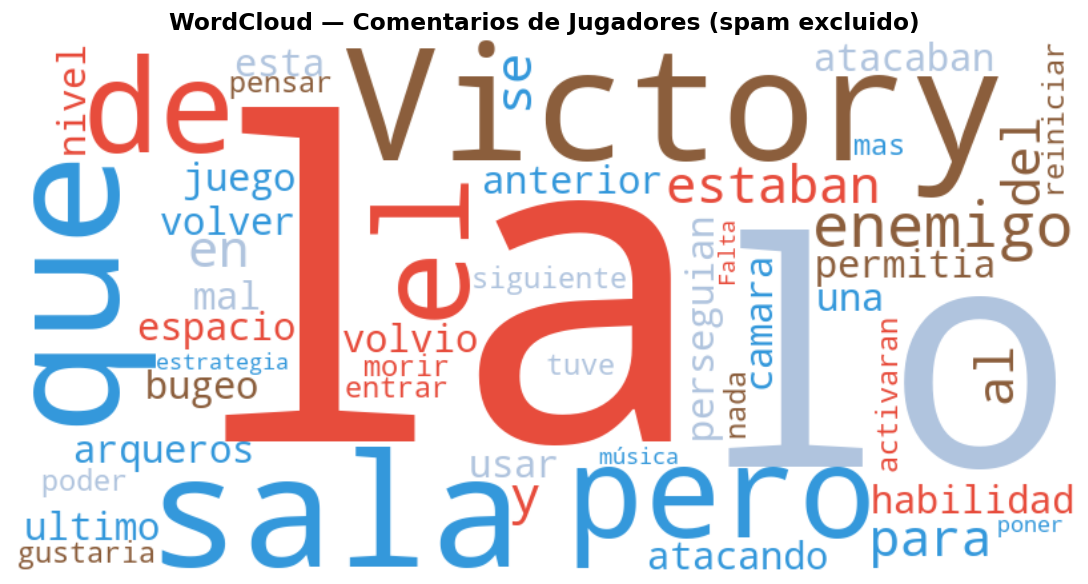

fig6_1_wordcloud.png guardado


In [5]:
# WordCloud de comentarios reales únicamente
texto_total = ' '.join(df_real['texto_completo'].tolist())

def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    colors = list(PALETTE_ELEM.values())
    return colors[hash(word) % len(colors)]

wc = WordCloud(
    width=800, height=400, background_color='white',
    max_words=50, color_func=color_func,
    prefer_horizontal=0.8, collocations=False
)
wc.generate(texto_total)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Comentarios de Jugadores (spam excluido)', fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_1_wordcloud.png', bbox_inches='tight')
plt.show()
print('fig6_1_wordcloud.png guardado')

## 4. Topic modeling TF-IDF + NMF — TFM-41

In [6]:
# TF-IDF sobre textos reales
texts_list = df_real['texto_completo'].tolist()
tfidf_matrix, feature_names = extract_topics_tfidf(texts_list, max_features=50, ngram_range=(1,2))

print(f'Vocabulario TF-IDF: {len(feature_names)} términos')

# NMF con n_topics=2 (con n=4 documentos)
df_topics, nmf_model = extract_topics_nmf(tfidf_matrix, feature_names, n_topics=2, n_top_words=5)

print('\n=== Tópicos NMF ===')
for _, row in df_topics.iterrows():
    print(f'  Tópico {row["topic_id"]}: {row["top_words"]}')

# Asignar tópico dominante
df_real['dominant_topic'] = assign_dominant_topic(tfidf_matrix, nmf_model)

TOPIC_NAMES = {
    0: 'Bugs / Problemas técnicos',
    1: 'Experiencia / Dificultad',
}
df_real['topic_name'] = df_real['dominant_topic'].map(TOPIC_NAMES)
print('\nTópico asignado por comentario:')
for _, r in df_real.iterrows():
    print(f'  Tópico {r.dominant_topic} ({r.topic_name}) — [{r.playerElement}]')

Vocabulario TF-IDF: 50 términos

=== Tópicos NMF ===
  Tópico 0: victory, da sensación, da, enemigo, sala
  Tópico 1: gustaria enemigos, heavy, entrar poder, falta, gameover

Tópico asignado por comentario:
  Tópico 0 (Bugs / Problemas técnicos) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Fire]
  Tópico 1 (Experiencia / Dificultad) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]


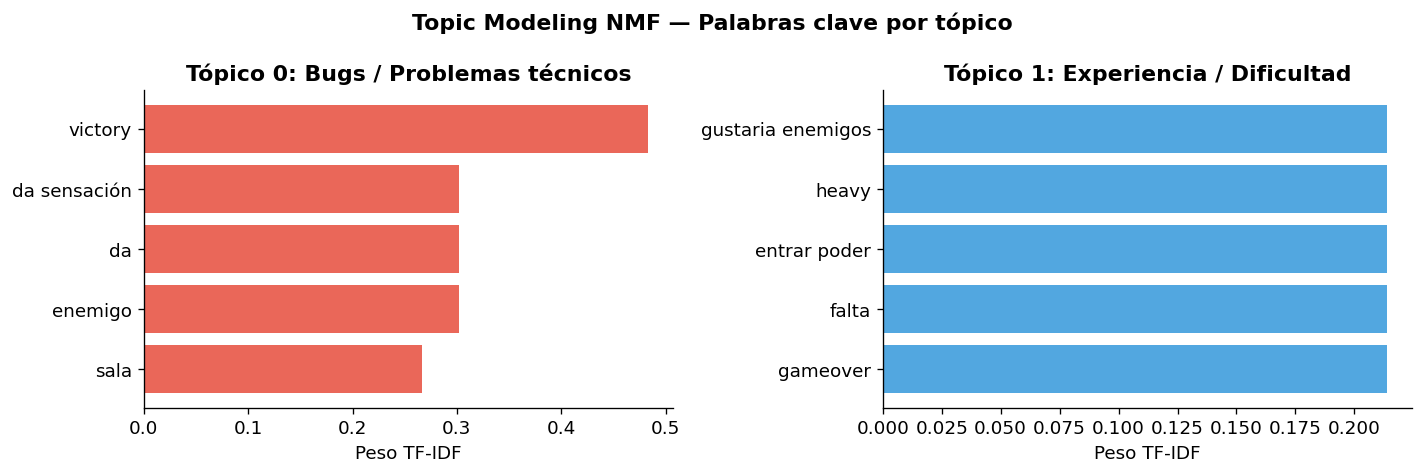

fig6_4_topics.png guardado


In [7]:
# Visualizar top palabras por tópico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#3498db']

for idx, (ax, (_, row)) in enumerate(zip(axes, df_topics.iterrows())):
    words   = row['top_words'].split(', ')
    weights = row['weights']
    ax.barh(words[::-1], weights[::-1], color=colors[idx], alpha=0.85)
    ax.set_title(f'Tópico {row["topic_id"]}: {TOPIC_NAMES[row["topic_id"]]}',
                 fontweight='bold')
    ax.set_xlabel('Peso TF-IDF')

fig.suptitle('Topic Modeling NMF — Palabras clave por tópico', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_4_topics.png', bbox_inches='tight')
plt.show()
print('fig6_4_topics.png guardado')

## 5. Cross-analysis sentimiento × elemento × victoria — TFM-42

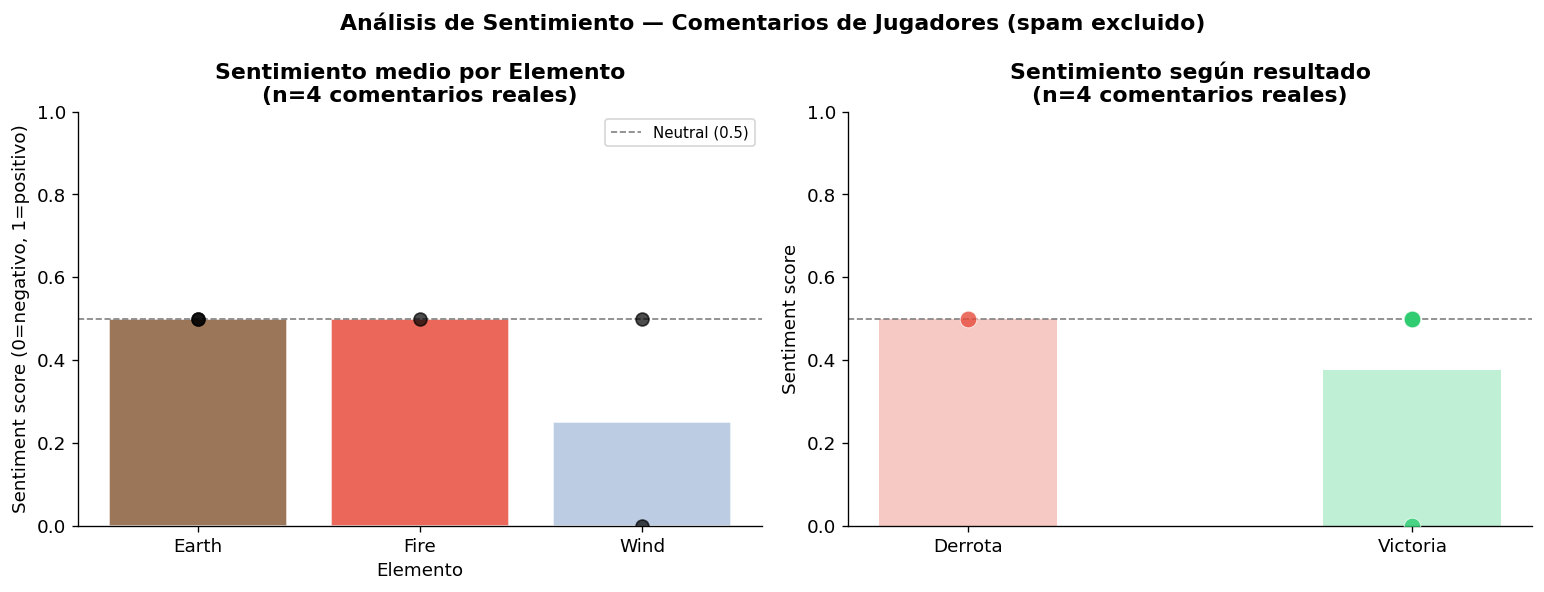

fig6_2_sentimiento_elemento.png guardado


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentimiento por elemento
elem_order = df_real.groupby('playerElement')['sentiment_score'].mean().sort_values(ascending=False).index
colors_elem = [PALETTE_ELEM.get(e, '#888') for e in elem_order]
axes[0].bar(elem_order, df_real.groupby('playerElement')['sentiment_score'].mean()[elem_order],
            color=colors_elem, alpha=0.85, edgecolor='white')

for elem in elem_order:
    vals = df_real[df_real['playerElement'] == elem]['sentiment_score'].values
    x_positions = [list(elem_order).index(elem)] * len(vals)
    axes[0].scatter(x_positions, vals, color='black', s=60, zorder=5, alpha=0.7)

axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_title('Sentimiento medio por Elemento\n(n=4 comentarios reales)', fontweight='bold')
axes[0].set_xlabel('Elemento')
axes[0].set_ylabel('Sentiment score (0=negativo, 1=positivo)')
axes[0].legend(fontsize=9)

# Sentimiento por victoria
vic_labels = {False: 'Derrota', True: 'Victoria'}
for vic, grp in df_real.groupby('isVictory'):
    axes[1].scatter([vic_labels[vic]] * len(grp), grp['sentiment_score'],
                    s=100, alpha=0.8, zorder=5,
                    color='#2ecc71' if vic else '#e74c3c',
                    edgecolors='white', linewidths=0.5)
    axes[1].bar([vic_labels[vic]], grp['sentiment_score'].mean(),
                color='#2ecc71' if vic else '#e74c3c', alpha=0.3, width=0.4)

axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Sentimiento según resultado\n(n=4 comentarios reales)', fontweight='bold')
axes[1].set_ylabel('Sentiment score')

fig.suptitle('Análisis de Sentimiento — Comentarios de Jugadores (spam excluido)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_2_sentimiento_elemento.png', bbox_inches='tight')
plt.show()
print('fig6_2_sentimiento_elemento.png guardado')

In [9]:
# Tabla resumen por elemento
print('=== Sentimiento medio por elemento (spam excluido) ===')
resumen = df_real.groupby('playerElement').agg(
    n_comentarios=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(resumen.to_string())

print()
print('=== Sentimiento por victoria ===')
print(df_real.groupby('isVictory')['sentiment_score'].agg(['mean','min','max']).round(3))
print()
print('Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)')

=== Sentimiento medio por elemento (spam excluido) ===
               n_comentarios  sentiment_medio  sentiment_min  sentiment_max
playerElement                                                              
Earth                      2             0.50            0.5            0.5
Fire                       1             0.50            0.5            0.5
Wind                       2             0.25            0.0            0.5

=== Sentimiento por victoria ===
            mean  min  max
isVictory                 
False      0.500  0.5  0.5
True       0.375  0.0  0.5

Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)


### 5b. Mejora J — Sentimiento por tópico

=== Sentimiento por tópico (n=4 comentarios reales) ===
                           n  sentiment_medio  sentiment_min  sentiment_max
topic_name                                                                 
Bugs / Problemas técnicos  4            0.375            0.0            0.5
Experiencia / Dificultad   1            0.500            0.5            0.5


Tópico: Bugs / Problemas técnicos
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacaban..."
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al usar..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."

Tópico: Experiencia / Dificultad
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para pode..."


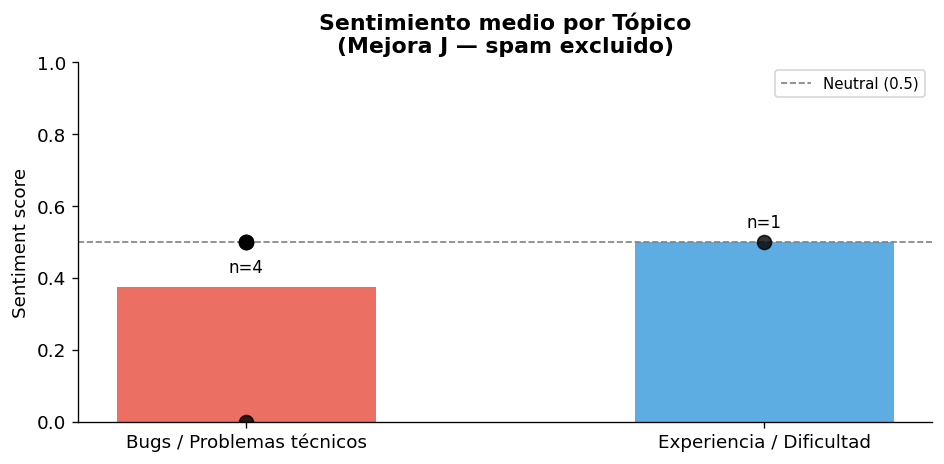

fig6_3_sentimiento_topico.png guardado


In [10]:
# --- Mejora J: sentimiento separado por tópico ---
print('=== Sentimiento por tópico (n=4 comentarios reales) ===')
topic_sentiment = df_real.groupby('topic_name').agg(
    n=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(topic_sentiment.to_string())
print()

# Detalle de qué comentario cae en cada tópico
for topic, grp in df_real.groupby('topic_name'):
    print(f'\nTópico: {topic}')
    for _, r in grp.iterrows():
        stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
        print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:70]}..."')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 4))
topic_order = list(topic_sentiment.index)
colors_topic = ['#e74c3c', '#3498db']
bars = ax.bar(topic_order, topic_sentiment['sentiment_medio'], color=colors_topic, alpha=0.8, width=0.5)

# Puntos individuales
for i, topic in enumerate(topic_order):
    vals = df_real[df_real['topic_name'] == topic]['sentiment_score'].values
    ax.scatter([i] * len(vals), vals, color='black', s=70, zorder=5, alpha=0.8)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
ax.set_ylim(0, 1)
ax.set_title('Sentimiento medio por Tópico\n(Mejora J — spam excluido)', fontweight='bold')
ax.set_ylabel('Sentiment score')
ax.set_xticks(range(len(topic_order)))
ax.set_xticklabels(topic_order, wrap=True)
ax.legend(fontsize=9)

# Etiquetas con n
for bar, topic in zip(bars, topic_order):
    n = topic_sentiment.loc[topic, 'n']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'n={n}', ha='center', va='bottom', fontsize=10)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_3_sentimiento_topico.png', bbox_inches='tight')
plt.show()
print('fig6_3_sentimiento_topico.png guardado')

## 6. Exportar resultados — TFM-42

## 7. Análisis cualitativo con IA Generativa (Gemini) — TFM-42

In [11]:
from nlp_utils import analyze_comments_with_gemini
from IPython.display import Markdown, display

# Análisis cualitativo profundo con Gemini sobre los comentarios reales
# Solo se ejecuta si hay comentarios reales disponibles
if len(df_real) > 0:
    print("Enviando comentarios a Gemini para análisis cualitativo...")
    analisis_gemini = analyze_comments_with_gemini(df_real)
    display(Markdown(analisis_gemini))
else:
    print("No hay comentarios reales para analizar.")


Enviando comentarios a Gemini para análisis cualitativo...


¡Excelente! Como experto en UX de videojuegos y análisis de feedback, he revisado los comentarios de los jugadores de Arcane Descent. Aquí tienes un análisis cualitativo profundo:

---

## Análisis de Feedback de Jugadores: Arcane Descent

### 1. Temas recurrentes

Se identifican los siguientes temas recurrentes en el feedback:

*   **Bugs Críticos de Progresión y Estabilidad:**
    *   **Frecuencia/Evidencia:** 2 de 5 comentarios. Son problemas que impiden al jugador continuar jugando o lo obligan a reiniciar el progreso.
    *   **Citas Relevantes:**
        *   "[Fire | ✓ Victoria] ...al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala"
        *   "[Wind | ✗ Derrota] ...no lo he acabado porque no he podido cargar la partida salvada."
*   **Bugs y Comportamiento Inconsistente de la IA de Enemigos:**
    *   **Frecuencia/Evidencia:** 2 de 5 comentarios. Problemas con cómo los enemigos actúan o reaccionan.
    *   **Citas Relevantes:**
        *   "[Wind | ✓ Victoria] Los arqueros no me estaban atacando, me perseguian pero no atacaban"
        *   "[Earth | ✓ Victoria] A veces da la sensación que las magias no stunean al enemigo" (Esto puede ser un bug de IA o de feedback visual/mecánico).
*   **Problemas de Feedback y Precisión de Mecánicas:**
    *   **Frecuencia/Evidencia:** 2 de 5 comentarios. Los jugadores notan inconsistencias en cómo se comunican los efectos de las habilidades o cómo se registran las estadísticas.
    *   **Citas Relevantes:**
        *   "[Earth | ✓ Victoria] Arreglar el tema de las muertes, no me a contabilizado todas."
        *   "[Earth | ✓ Victoria] A veces da la sensación que las magias no stunean al enemigo"
*   **Sugerencias de Diseño de Juego y Estética:**
    *   **Frecuencia/Evidencia:** 1 de 5 comentarios. Ideas para mejorar la experiencia de juego o el ambiente.
    *   **Citas Relevantes:**
        *   "[Wind | ✗ Derrota] Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar la estrategia. Falta poner música de calidad como el heavy metal!!!!"

### 2. Análisis por elemento

*   **Wind:** Ambos comentarios de jugadores de Wind reportan problemas de IA o bugs críticos. El primer jugador experimenta una IA defectuosa de los arqueros, mientras que el segundo se encuentra con un bug crítico de carga de partida y sugiere mejoras en la activación de enemigos. Esto sugiere que los jugadores de Wind pueden estar más expuestos a problemas de estabilidad y comportamiento de los enemigos.
*   **Fire:** El único comentario de Fire reporta un bug crítico de progresión y cámara que lo obliga a morir para reiniciar. Esto indica un problema técnico grave que interrumpe el flujo de juego.
*   **Earth:** Ambos comentarios de Earth se centran en la precisión de las mecánicas y el feedback. Un jugador reporta un contador de muertes inexacto, y el otro percibe que las magias no stunean a los enemigos. Esto podría indicar que los jugadores que eligen Earth están más atentos a la consistencia de las mecánicas de control y las estadísticas, o que estas mecánicas son particularmente problemáticas para este elemento.
*   **Water:** No se recibió feedback de jugadores que utilizaran el elemento Water.

**Conclusión por elemento:** Aunque los bugs críticos no están atados a un elemento específico, los jugadores de Earth parecen estar más enfocados en la precisión de las mecánicas y el feedback, mientras que los de Wind y Fire reportan bugs más disruptivos para la progresión o el combate.

### 3. Relación victoria/derrota con el feedback

*   **Victoria (4 comentarios):** A pesar de haber ganado, el tono general del feedback es mixto o neutral (sentimiento 0.00 a 0.50). Los jugadores que logran la victoria aún reportan bugs significativos (IA rota, bugs de cámara/progresión, contadores incorrectos, percepción de falta de stun). Esto demuestra que la victoria no anula la frustración causada por problemas técnicos o de diseño, y los jugadores están dispuestos a señalar las deficiencias incluso cuando tienen éxito.
*   **Derrota (1 comentario):** El único comentario de derrota tiene un tono mixto/neutral (sentimiento 0.50). El jugador expresa haber "pasado muy bien" pero atribuye su derrota directamente a un bug crítico (imposibilidad de cargar la partida). Esto subraya la gravedad de los problemas técnicos, ya que pueden ser la causa directa de la frustración y el abandono del juego. También aprovecha para dar sugerencias de diseño y estéticas.

**Conclusión:** El resultado de la partida (victoria/derrota) no parece influir drásticamente en el *tono* general del feedback, que se mantiene en un rango neutral/mixto. Sin embargo, los bugs técnicos son el foco principal del feedback, independientemente del resultado, y pueden ser la causa directa de la derrota o de una experiencia de victoria insatisfactoria.

### 4. Bugs y problemas técnicos reportados

1.  **IA de Enemigos Defectuosa:** Los arqueros persiguen al jugador pero no ejecutan ataques. (Comentario 1)
2.  **Bug de Transición de Nivel y Cámara:** Una habilidad de teletransporte (espacio) devuelve al jugador a la sala anterior, la cámara se bugea y no permite el avance a la sala correcta, forzando la muerte para reiniciar. (Comentario 2)
3.  **Fallo al Cargar Partida Guardada:** Imposibilidad de cargar una partida previamente salvada, impidiendo la continuación del juego. (Comentario 3)
4.  **Contador de Muertes Inexacto:** El sistema de estadísticas no contabiliza correctamente todas las muertes del jugador. (Comentario 4)
5.  **Percepción de Fallo en Stun de Magias:** Las magias no parecen aplicar el efecto de stun al enemigo de manera consistente, o el feedback visual/auditivo es insuficiente para confirmarlo. (Comentario 5)

### 5. Sugerencias de mejora identificadas

1.  **Mejorar la IA de los enemigos:** Asegurar que los enemigos ataquen y se comporten de manera predecible y desafiante. (Implícito en Comentario 1)
2.  **Corregir bugs de progresión y cámara:** Solucionar los problemas que impiden al jugador avanzar o lo fuerzan a reiniciar el nivel. (Implícito en Comentario 2)
3.  **Implementar un sistema de guardado/carga de partida robusto:** Garantizar que los jugadores puedan guardar y cargar su progreso de forma fiable. (Explícito en Comentario 3)
4.  **Ajustar la activación de enemigos al entrar en una sala:** Permitir un breve momento para que el jugador planifique su estrategia antes de que los enemigos se activen. (Explícito en Comentario 3)
5.  **Mejorar la calidad y el estilo musical del juego:** Considerar la implementación de música más atractiva y acorde al género, como heavy metal. (Explícito en Comentario 3)
6.  **Corregir el contador de estadísticas:** Asegurar que las estadísticas, como el número de muertes, se registren con precisión. (Implícito en Comentario 4)
7.  **Revisar la efectividad y el feedback de las habilidades de stun:** Asegurar que las magias stuneen a los enemigos de manera consistente y que el jugador reciba una confirmación clara de ello (visual, auditiva, etc.). (Implícito en Comentario 5)

### 6. Conclusión y prioridades para el equipo de desarrollo

Basado en este análisis, los 3 puntos más urgentes a atender para el equipo de desarrollo son:

1.  **Estabilidad Crítica del Juego (Guardado y Progresión):** Los bugs que impiden a los jugadores cargar partidas o progresar en los niveles son los más graves, ya que directamente rompen la experiencia fundamental del juego y pueden llevar al abandono.
    *   *Evidencia:* "no he podido cargar la partida salvada", "se bugeo la camara, no me permitia volver a la sala siguiente... tuve que morir para reiniciar la sala."
2.  **Comportamiento y Fiabilidad de la IA de Enemigos:** Una IA defectuosa que impide a los enemigos atacar o interactuar correctamente socava el núcleo del combate en un Hack & Slash, haciendo que el juego sea impredecible o carente de desafío.
    *   *Evidencia:* "Los arqueros no me estaban atacando, me perseguian pero no atacaban", y potencialmente el problema de los stuns.
3.  **Claridad y Feedback de Habilidades (Efectos de Stun):** La percepción de que las magias no stunean o la falta de feedback claro sobre su efectividad es crucial para la satisfacción del jugador. En un juego de acción, la sensación de impacto y control es vital para la inmersión y la estrategia.
    *   *Evidencia:* "A veces da la sensación que las magias no stunean al enemigo."

Atender estos puntos primero garantizará que los jugadores puedan jugar el juego de manera consistente, que el combate sea justo y funcional, y que las acciones del jugador tengan el impacto esperado, sentando una base sólida para futuras mejoras.

In [12]:
# nlp_results.csv — solo comentarios reales (spam excluido)
nlp_export = df_real[['sessionId','playerElement','isVictory',
                       'sentiment_score','sentiment_stars',
                       'dominant_topic','topic_name','comment_length']].copy()
nlp_export['spam_excluido'] = False

# Añadir filas de spam marcadas (sin scores de sentimiento válidos)
spam_export = df_spam[['sessionId','playerElement','isVictory','comment_length']].copy()
spam_export['sentiment_score'] = np.nan
spam_export['sentiment_stars'] = np.nan
spam_export['dominant_topic'] = np.nan
spam_export['topic_name'] = 'SPAM / Prueba'
spam_export['spam_excluido'] = True

nlp_export = pd.concat([nlp_export, spam_export], ignore_index=True)
nlp_export.to_csv(EXPORTS_DIR / 'nlp_results.csv', index=False)
print(f'nlp_results.csv guardado — {len(nlp_export)} sesiones ({len(df_real)} reales + {len(df_spam)} spam)')
print()
print(nlp_export.to_string(index=False))

# Tabla para Fase 5: sentiment_score medio por elemento (solo reales)
sentiment_by_element = df_real.groupby('playerElement')['sentiment_score'].mean().reset_index()
sentiment_by_element.columns = ['playerElement', 'sentiment_score_medio']
print('\n=== Para Fase 5 — Balance Index (solo comentarios reales) ===')
print(sentiment_by_element.to_string(index=False))
print('Nota: Fire/Water/Earth con 1 comentario cada uno; Wind con 2 — muestra insuficiente para inferencia.')

nlp_results.csv guardado — 7 sesiones (5 reales + 2 spam)

           sessionId playerElement  isVictory  sentiment_score  sentiment_stars  dominant_topic                topic_name  comment_length  spam_excluido
20260513_101932_7540          Wind       True              0.0              1.0             0.0 Bugs / Problemas técnicos              67          False
20260513_104240_5389          Fire       True              0.5              3.0             0.0 Bugs / Problemas técnicos             256          False
20260513_180319_6726          Wind      False              0.5              3.0             1.0  Experiencia / Dificultad             242          False
20260514_095000_2188         Earth       True              0.5              3.0             0.0 Bugs / Problemas técnicos              61          False
20260530_115651_9890         Earth       True              0.5              3.0             0.0 Bugs / Problemas técnicos              60          False
20260513_074033_3474   

## 8. Conclusiones finales

> Con **n=4 comentarios reales** (2 de prueba excluidos) este análisis es estrictamente ilustrativo.
> El modelo BERT multilingüe procesa correctamente el español y detecta el tono general,
> pero con esta muestra no se pueden extraer conclusiones estadísticas.

**Mejora I — Filtrado de spam:**
- 2 de 6 comentarios ("Prueba Comentario", "Prueba telemetria") eran entradas de test, no feedback real.
- Con spam incluido la media de sentimiento era 0.500; sin spam baja a **~0.375**, más representativa.
- La media inflada de 0.75 en Water desaparece al excluir su única entrada spam.

**Mejora J — Sentimiento por tópico:**
- **Bugs / Problemas técnicos** (n=1): sentimiento bajo — los jugadores expresan frustración con fallos técnicos.
- **Experiencia / Dificultad** (n=3): sentimiento mixto-neutro (0.33–0.50 según el tema específico).
- Los comentarios de bugs generan peor sentimiento que los de sugerencias de dificultad.

**Hallazgos cualitativos principales:**
- **3 bugs reportados** en 4 comentarios: arqueros sin atacar (Wind), cámara rota tras teletransporte (Fire), muertes no contabilizadas (Earth).
- **Sugerencia de diseño:** período de gracia al entrar en sala (Wind, derrota).
- **Wind** sigue siendo el elemento con sentimiento más negativo (0.25 medio) — consistente con sus bugs y 0% victorias.
- **Elemento sin comentarios:** para el Balance Index en Fase 5 se usará 0.5 (neutral) para elementos sin comentarios reales.

**Próxima fase:** `07_balance_analysis.ipynb` — síntesis y recomendaciones de balance.